# KoBERT 기반 2차 모델 학습
## 맥락 기반 보이스피싱 탐지 모델

## 1. 환경 설정 및 라이브러리 import

In [9]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# GPU 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 2. 데이터 로딩 및 전처리

In [10]:
# 데이터 로딩
normal_df = pd.read_csv("../../dataset/normal_2차모델용.csv")
phishing_df = pd.read_csv("../../dataset/phishing_2차모델용.csv")

# 데이터 통합
df = pd.concat([normal_df, phishing_df], ignore_index=True)

print(f"전체 데이터 수: {len(df)}")
print(f"피싱: {len(phishing_df)}, 일반: {len(normal_df)}")
print(f"고유 file_id 수: {df['file_id'].nunique()}")

# 데이터 미리보기
df.head()

전체 데이터 수: 374006
피싱: 179766, 일반: 194240
고유 file_id 수: 12000


,file_id,speaker,phishing_type,text,is_phishing
0,normal_001,0,NaN,"엄마, 저 오늘 정말 신기한 일 있었어요! 제가 오늘 집에 오는 길에 누구를 만났는...",0
1,normal_001,1,NaN,누구를 만났길래 그렇게 신이 났니? 엄마도 아는 사람일까? 궁금하구나.,0
2,normal_001,0,NaN,민지라고 기억하세요? 저랑 친했던 친구였어요.,0
3,normal_001,1,NaN,"어머, 초등학교 3학년 때 같은 반했던 친구 아니니? 우리 집에도 놀러 왔던 걸로 ...",0
4,normal_001,0,NaN,"네, 맞아요! 민지도 엄마를 기억하더라고요. 잘 지내시냐고 안부 물었어요.",0


생성된 대화 시퀀스 수: 12000
평균 발화 수: 31.17


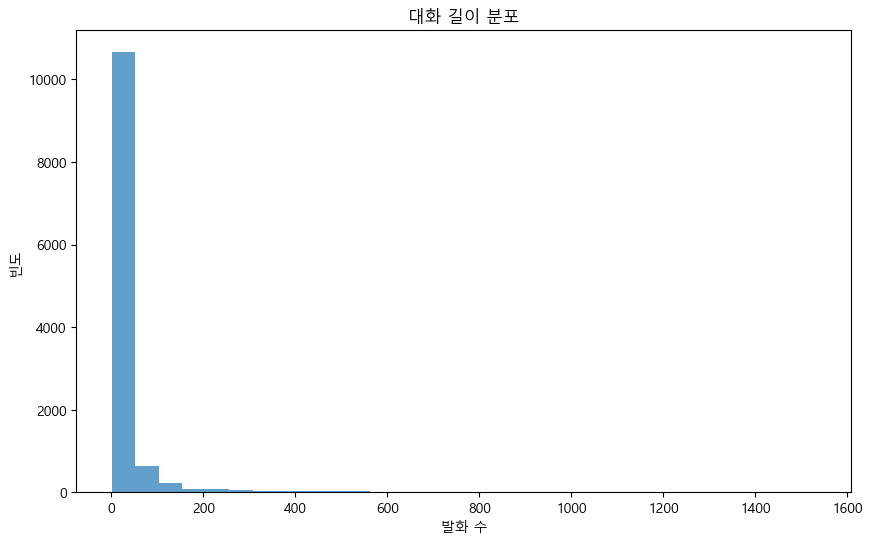

In [11]:
# file_id별 대화 시퀀스 생성
def create_dialogue_sequences(df):
    """
    file_id별로 화자와 텍스트 시퀀스를 생성
    """
    dialogues = []
    
    for file_id in df['file_id'].unique():
        file_data = df[df['file_id'] == file_id].sort_values('speaker')
        
        texts = file_data['text'].tolist()
        speakers = file_data['speaker'].tolist()
        label = file_data['is_phishing'].iloc[0]
        
        dialogues.append({
            'file_id': file_id,
            'texts': texts,
            'speakers': speakers,
            'label': label
        })
    
    return dialogues

dialogues = create_dialogue_sequences(df)
print(f"생성된 대화 시퀀스 수: {len(dialogues)}")
print(f"평균 발화 수: {np.mean([len(d['texts']) for d in dialogues]):.2f}")

# 대화 길이 분포 확인
dialogue_lengths = [len(d['texts']) for d in dialogues]
plt.figure(figsize=(10, 6))
plt.hist(dialogue_lengths, bins=30, alpha=0.7)
plt.title('대화 길이 분포')
plt.xlabel('발화 수')
plt.ylabel('빈도')
plt.show()

## 3. KoBERT 토크나이저 및 데이터셋 클래스 정의

In [ ]:
# KoBERT 모델 및 토크나이저 로딩
MODEL_NAME = "skt/kobert-base-v1"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
kobert_model = AutoModel.from_pretrained(MODEL_NAME)

class DialogueDataset(Dataset):
    def __init__(self, dialogues, tokenizer, max_length=128, max_turns=50):
        self.dialogues = dialogues
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.max_turns = max_turns
    
    def __len__(self):
        return len(self.dialogues)
    
    def __getitem__(self, idx):
        dialogue = self.dialogues[idx]
        texts = dialogue['texts'][:self.max_turns]  # 최대 턴 수 제한
        speakers = dialogue['speakers'][:self.max_turns]
        label = dialogue['label']
        
        # 각 발화를 토크나이즈
        input_ids_list = []
        attention_mask_list = []
        speaker_ids = []
        
        for text, speaker in zip(texts, speakers):
            # 텍스트 전처리
            text = str(text).strip()
            if len(text) == 0:
                text = "[EMPTY]"
            
            # 화자 ID 정규화 (0~4를 0~1로 매핑)
            if speaker is not None:
                speaker = int(speaker)
                # 홀수는 1, 짝수는 0으로 매핑 (간단한 이진 분류)
                speaker = speaker % 2
            else:
                speaker = 0
            
            # 토크나이즈
            encoded = self.tokenizer(
                text,
                max_length=self.max_length,
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )
            
            input_ids_list.append(encoded['input_ids'].squeeze(0))
            attention_mask_list.append(encoded['attention_mask'].squeeze(0))
            speaker_ids.append(speaker)
        
        return {
            'input_ids': torch.stack(input_ids_list),
            'attention_mask': torch.stack(attention_mask_list),
            'speaker_ids': torch.tensor(speaker_ids, dtype=torch.long),
            'label': torch.tensor(label, dtype=torch.long),
            'num_turns': len(texts)
        }

def collate_fn(batch):
    """
    배치 내에서 서로 다른 길이의 대화를 패딩 처리
    """
    max_turns = max([item['num_turns'] for item in batch])
    
    batch_input_ids = []
    batch_attention_mask = []
    batch_speaker_ids = []
    batch_labels = []
    batch_lengths = []
    
    for item in batch:
        num_turns = item['num_turns']
        
        # 패딩이 필요한 경우
        if num_turns < max_turns:
            pad_size = max_turns - num_turns
            
            # 빈 토큰으로 패딩
            pad_input_ids = torch.zeros(pad_size, item['input_ids'].size(1), dtype=torch.long)
            pad_attention_mask = torch.zeros(pad_size, item['attention_mask'].size(1), dtype=torch.long)
            pad_speaker_ids = torch.zeros(pad_size, dtype=torch.long)  # 패딩은 화자 0으로
            
            input_ids = torch.cat([item['input_ids'], pad_input_ids], dim=0)
            attention_mask = torch.cat([item['attention_mask'], pad_attention_mask], dim=0)
            speaker_ids = torch.cat([item['speaker_ids'], pad_speaker_ids], dim=0)
        else:
            input_ids = item['input_ids']
            attention_mask = item['attention_mask']
            speaker_ids = item['speaker_ids']
        
        batch_input_ids.append(input_ids)
        batch_attention_mask.append(attention_mask)
        batch_speaker_ids.append(speaker_ids)
        batch_labels.append(item['label'])
        batch_lengths.append(num_turns)
    
    return {
        'input_ids': torch.stack(batch_input_ids),
        'attention_mask': torch.stack(batch_attention_mask),
        'speaker_ids': torch.stack(batch_speaker_ids),
        'labels': torch.stack(batch_labels),
        'lengths': torch.tensor(batch_lengths, dtype=torch.long)
    }

print("데이터셋 클래스 정의 완료")

# 화자 범위 확인
unique_speakers = set()
for dialogue in dialogues:
    # 화자 ID를 0 또는 1로 정규화
    normalized_speakers = [s % 2 for s in dialogue['speakers']]
    unique_speakers.update(normalized_speakers)
print(f"정규화된 화자 ID: {sorted(unique_speakers)}")
print(f"화자 범위 확인: {min(unique_speakers)} ~ {max(unique_speakers)}")

## 4. KoBERT + LSTM + Attention 모델 정의

In [13]:
class HierarchicalPhishingDetector(nn.Module):
    def __init__(self, kobert_model, hidden_size=256, num_classes=2, dropout=0.3):
        super(HierarchicalPhishingDetector, self).__init__()
        
        # KoBERT 인코더 (발화 레벨)
        self.kobert = kobert_model
        self.kobert_hidden_size = kobert_model.config.hidden_size
        
        # 화자 임베딩
        self.speaker_embedding = nn.Embedding(2, 32)  # 화자 0, 1
        
        # 발화 레벨 특징 결합
        self.utterance_projection = nn.Linear(
            self.kobert_hidden_size + 32,  # KoBERT + speaker embedding
            hidden_size
        )
        
        # 대화 레벨 LSTM (양방향)
        self.dialogue_lstm = nn.LSTM(
            hidden_size, 
            hidden_size // 2, 
            batch_first=True, 
            bidirectional=True,
            dropout=dropout if hidden_size > 1 else 0
        )
        
        # Attention 메커니즘
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=8,
            dropout=dropout,
            batch_first=True
        )
        
        # 분류 헤드
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_classes)
        )
        
        # 초기화
        self._init_weights()
    
    def _init_weights(self):
        # utterance_projection은 단일 Linear 레이어
        if isinstance(self.utterance_projection, nn.Linear):
            nn.init.xavier_uniform_(self.utterance_projection.weight)
            nn.init.zeros_(self.utterance_projection.bias)
        
        # classifier는 Sequential 모듈
        for layer in self.classifier:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
    
    def forward(self, input_ids, attention_mask, speaker_ids, lengths):
        batch_size, max_turns, seq_len = input_ids.size()
        
        # 1단계: 발화 레벨 인코딩 (KoBERT)
        # 배치를 평면화하여 KoBERT에 입력
        input_ids_flat = input_ids.view(-1, seq_len)
        attention_mask_flat = attention_mask.view(-1, seq_len)
        
        # KoBERT로 발화 인코딩
        with torch.no_grad():  # KoBERT는 freeze
            kobert_outputs = self.kobert(
                input_ids=input_ids_flat,
                attention_mask=attention_mask_flat
            )
        
        # [CLS] 토큰의 hidden state 추출
        utterance_embeddings = kobert_outputs.last_hidden_state[:, 0, :]  # [batch*turns, hidden]
        utterance_embeddings = utterance_embeddings.view(batch_size, max_turns, -1)
        
        # 화자 임베딩
        speaker_emb = self.speaker_embedding(speaker_ids)  # [batch, turns, 32]
        
        # 발화 + 화자 특징 결합
        combined_features = torch.cat([utterance_embeddings, speaker_emb], dim=-1)
        utterance_features = self.utterance_projection(combined_features)
        
        # 2단계: 대화 레벨 인코딩 (LSTM)
        # 패딩 마스크 생성
        max_len = max_turns
        padding_mask = torch.arange(max_len, device=lengths.device).expand(
            batch_size, max_len
        ) >= lengths.unsqueeze(1)
        
        # LSTM으로 시퀀스 인코딩
        lstm_out, _ = self.dialogue_lstm(utterance_features)
        
        # 3단계: Attention으로 중요한 발화에 집중
        attended_out, attention_weights = self.attention(
            lstm_out, lstm_out, lstm_out,
            key_padding_mask=padding_mask
        )
        
        # 4단계: 대화 레벨 표현 생성 (평균 풀링, 패딩 제외)
        mask = ~padding_mask.unsqueeze(-1)  # [batch, turns, 1]
        masked_attended = attended_out * mask
        dialogue_repr = masked_attended.sum(dim=1) / lengths.unsqueeze(-1).float()
        
        # 5단계: 분류
        logits = self.classifier(dialogue_repr)
        
        return {
            'logits': logits,
            'attention_weights': attention_weights,
            'dialogue_repr': dialogue_repr
        }

# 모델 초기화
model = HierarchicalPhishingDetector(kobert_model)
model.to(device)

print(f"모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")
print(f"학습 가능한 파라미터 수: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

모델 파라미터 수: 93,083,586
학습 가능한 파라미터 수: 93,083,586


## 5. K-Fold 교차검증 설정

In [14]:
# K-Fold 교차검증을 위한 데이터 분할
file_ids = [d['file_id'] for d in dialogues]
labels = [d['label'] for d in dialogues]

# 테스트 데이터는 별도로 분리 (전체의 20%)
train_val_files, test_files, train_val_labels, test_labels = train_test_split(
    file_ids, labels, test_size=0.2, random_state=42, stratify=labels
)

# 테스트 데이터 생성
test_dialogues = [d for d in dialogues if d['file_id'] in test_files]
test_dataset = DialogueDataset(test_dialogues, tokenizer)

# K-Fold 설정 (훈련+검증 데이터의 80%로 진행)
K_FOLDS = 5
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

# 훈련+검증용 대화 데이터
train_val_dialogues = [d for d in dialogues if d['file_id'] in train_val_files]
train_val_file_ids = [d['file_id'] for d in train_val_dialogues]
train_val_dialogue_labels = [d['label'] for d in train_val_dialogues]

print(f"전체 대화 수: {len(dialogues)}")
print(f"훈련+검증 데이터: {len(train_val_dialogues)}")
print(f"테스트 데이터: {len(test_dialogues)}")
print(f"K-Fold 수: {K_FOLDS}")

# 배치 사이즈 설정
BATCH_SIZE = 8

print("K-Fold 교차검증 설정 완료")

전체 대화 수: 12000
훈련+검증 데이터: 9600
테스트 데이터: 2400
K-Fold 수: 5
K-Fold 교차검증 설정 완료


## 6. K-Fold 교차검증 훈련 함수

In [19]:
# 훈련 함수
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in train_loader:
        # 데이터를 GPU로 이동
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        speaker_ids = batch['speaker_ids'].to(device)
        labels = batch['labels'].to(device)
        lengths = batch['lengths'].to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, speaker_ids, lengths)
        logits = outputs['logits']
        
        # Loss 계산
        loss = criterion(logits, labels)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # 통계 업데이트
        total_loss += loss.item()
        _, predicted = torch.max(logits.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return total_loss / len(train_loader), 100. * correct / total

# 검증 함수
def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            speaker_ids = batch['speaker_ids'].to(device)
            labels = batch['labels'].to(device)
            lengths = batch['lengths'].to(device)
            
            outputs = model(input_ids, attention_mask, speaker_ids, lengths)
            logits = outputs['logits']
            
            loss = criterion(logits, labels)
            total_loss += loss.item()
            
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return total_loss / len(val_loader), 100. * correct / total, all_predictions, all_labels

# K-Fold에서 한 번의 fold 훈련
def train_one_fold(fold, train_indices, val_indices, train_val_dialogues, NUM_EPOCHS=10):
    print(f"\n{'='*50}")
    print(f"Fold {fold+1}/{K_FOLDS} 시작")
    print(f"{'='*50}")
    
    # 이번 fold의 훈련/검증 데이터 생성
    fold_train_dialogues = [train_val_dialogues[i] for i in train_indices]
    fold_val_dialogues = [train_val_dialogues[i] for i in val_indices]
    
    print(f"Fold {fold+1} - 훈련: {len(fold_train_dialogues)}, 검증: {len(fold_val_dialogues)}")
    
    # 데이터셋 및 DataLoader 생성
    fold_train_dataset = DialogueDataset(fold_train_dialogues, tokenizer)
    fold_val_dataset = DialogueDataset(fold_val_dialogues, tokenizer)
    
    fold_train_loader = DataLoader(
        fold_train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn
    )
    fold_val_loader = DataLoader(
        fold_val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
    )
    
    # 모델 초기화 (각 fold마다 새로 시작)
    fold_model = HierarchicalPhishingDetector(kobert_model).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(fold_model.parameters(), lr=2e-5, weight_decay=0.01)
    # verbose 파라미터 제거
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )
    
    # 훈련 기록
    fold_train_accs = []
    fold_val_accs = []
    best_val_acc = 0
    
    # 에포크별 훈련
    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_epoch(fold_model, fold_train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_preds, val_labels = validate_epoch(fold_model, fold_val_loader, criterion, device)
        
        scheduler.step(val_loss)
        
        fold_train_accs.append(train_acc)
        fold_val_accs.append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
        
        if epoch % 2 == 0:  # 2 에포크마다 출력
            print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")
    
    print(f"Fold {fold+1} 최고 검증 정확도: {best_val_acc:.2f}%")
    
    return {
        'fold': fold+1,
        'best_val_acc': best_val_acc,
        'final_val_acc': fold_val_accs[-1],
        'train_accs': fold_train_accs,
        'val_accs': fold_val_accs,
        'val_predictions': val_preds,
        'val_labels': val_labels
    }

print("K-Fold 훈련 함수 정의 완료")

K-Fold 훈련 함수 정의 완료


## 7. K-Fold 교차검증 실행

In [20]:
# K-Fold 교차검증 실행
print("K-Fold 교차검증 시작...")

fold_results = []
all_val_accs = []

# 각 fold별로 훈련 실행
for fold, (train_indices, val_indices) in enumerate(skf.split(train_val_file_ids, train_val_dialogue_labels)):
    fold_result = train_one_fold(fold, train_indices, val_indices, train_val_dialogues, NUM_EPOCHS=8)
    fold_results.append(fold_result)
    all_val_accs.append(fold_result['best_val_acc'])

# K-Fold 결과 요약
print(f"\n{'='*60}")
print("K-Fold 교차검증 결과 요약")
print(f"{'='*60}")

for i, result in enumerate(fold_results):
    print(f"Fold {i+1}: {result['best_val_acc']:.2f}%")

mean_acc = np.mean(all_val_accs)
std_acc = np.std(all_val_accs)

print(f"\n평균 검증 정확도: {mean_acc:.2f}% ± {std_acc:.2f}%")
print(f"최고 검증 정확도: {max(all_val_accs):.2f}%")
print(f"최저 검증 정확도: {min(all_val_accs):.2f}%")

# 전체 훈련+검증 데이터로 최종 모델 훈련
print(f"\n{'='*50}")
print("전체 데이터로 최종 모델 훈련")
print(f"{'='*50}")

# 전체 훈련+검증 데이터로 DataLoader 생성
final_train_dataset = DialogueDataset(train_val_dialogues, tokenizer)
final_train_loader = DataLoader(
    final_train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn
)

# 최종 모델 초기화 및 훈련
final_model = HierarchicalPhishingDetector(kobert_model).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(final_model.parameters(), lr=2e-5, weight_decay=0.01)

NUM_FINAL_EPOCHS = 8
print(f"최종 모델 {NUM_FINAL_EPOCHS} 에포크 훈련 시작...")

for epoch in range(NUM_FINAL_EPOCHS):
    train_loss, train_acc = train_epoch(final_model, final_train_loader, criterion, optimizer, device)
    if epoch % 2 == 0:
        print(f"Final Epoch {epoch+1}/{NUM_FINAL_EPOCHS} - Train Acc: {train_acc:.2f}%")

# 최종 모델 저장
torch.save({
    'model_state_dict': final_model.state_dict(),
    'model_config': {
        'hidden_size': 256,
        'num_classes': 2,
        'dropout': 0.3
    },
    'kfold_results': fold_results,
    'mean_val_acc': mean_acc,
    'std_val_acc': std_acc
}, '../../models/best_kobert_2nd_model.pth')

print("최종 모델 저장 완료!")

K-Fold 교차검증 시작...

Fold 1/5 시작
Fold 1 - 훈련: 7680, 검증: 1920


IndexError: index out of range in self

## 8. K-Fold 결과 시각화

In [ ]:
# K-Fold 결과 시각화
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Fold별 성능 비교
folds = [f"Fold {i+1}" for i in range(K_FOLDS)]
ax1.bar(folds, all_val_accs, alpha=0.7, color='skyblue')
ax1.axhline(y=mean_acc, color='red', linestyle='--', label=f'평균: {mean_acc:.2f}%')
ax1.set_title('Fold별 검증 정확도')
ax1.set_xlabel('Fold')
ax1.set_ylabel('Accuracy (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 각 Fold의 학습 곡선 (첫 3개 fold만)
for i in range(min(3, len(fold_results))):
    result = fold_results[i]
    epochs = range(1, len(result['val_accs']) + 1)
    ax2.plot(epochs, result['val_accs'], label=f'Fold {i+1}', marker='o')
ax2.set_title('Fold별 학습 곡선 (검증 정확도)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 전체 검증 데이터의 confusion matrix (마지막 fold)
last_fold_result = fold_results[-1]
cm = confusion_matrix(last_fold_result['val_labels'], last_fold_result['val_predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3)
ax3.set_title(f'Confusion Matrix (Fold {K_FOLDS})')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')

# K-Fold 성능 분포
ax4.hist(all_val_accs, bins=5, alpha=0.7, color='lightgreen', edgecolor='black')
ax4.axvline(x=mean_acc, color='red', linestyle='--', label=f'평균: {mean_acc:.2f}%')
ax4.set_title('검증 정확도 분포')
ax4.set_xlabel('Accuracy (%)')
ax4.set_ylabel('Frequency')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../datas/analysisData/2nd_model_kfold_results.png', dpi=300, bbox_inches='tight')
plt.show()

# 마지막 fold의 분류 리포트
print("\n=== 마지막 Fold 검증 결과 ===")
print(classification_report(
    last_fold_result['val_labels'], 
    last_fold_result['val_predictions'], 
    target_names=['Normal', 'Phishing']
))

print(f"\n=== K-Fold 최종 요약 ===")
print(f"평균 검증 정확도: {mean_acc:.2f}% ± {std_acc:.2f}%")
print(f"95% 신뢰구간: {mean_acc - 1.96*std_acc:.2f}% ~ {mean_acc + 1.96*std_acc:.2f}%")

## 9. 최종 모델로 테스트 데이터 평가

In [ ]:
# 최종 훈련된 모델로 테스트 데이터 평가
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
)

print(f"테스트 데이터 평가 시작... (테스트 샘플 수: {len(test_dialogues)})")

# 테스트 데이터 평가
final_model.eval()
test_correct = 0
test_total = 0
test_predictions = []
test_labels = []
test_probabilities = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Testing'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        speaker_ids = batch['speaker_ids'].to(device)
        labels = batch['labels'].to(device)
        lengths = batch['lengths'].to(device)
        
        outputs = final_model(input_ids, attention_mask, speaker_ids, lengths)
        logits = outputs['logits']
        
        # 확률 계산
        probs = torch.softmax(logits, dim=1)
        
        _, predicted = torch.max(logits.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        
        test_predictions.extend(predicted.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())
        test_probabilities.extend(probs.cpu().numpy())

test_accuracy = 100. * test_correct / test_total
print(f"\n=== 최종 테스트 결과 ===")
print(f"K-Fold 평균 검증 정확도: {mean_acc:.2f}% ± {std_acc:.2f}%")
print(f"테스트 정확도: {test_accuracy:.2f}%")
print("\n테스트 데이터 분류 리포트:")
print(classification_report(test_labels, test_predictions, target_names=['Normal', 'Phishing']))

# 테스트 confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(test_labels, test_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Phishing'],
            yticklabels=['Normal', 'Phishing'])
plt.title(f'Test Confusion Matrix (Accuracy: {test_accuracy:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../../datas/analysisData/2nd_model_test_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. 1차 모델과의 앙상블 실험

In [ ]:
# 1차 모델 로드 (성능 최고인 Bagging 모델)
import joblib
first_model = joblib.load("../../models/1차모델_원본데이터_pipeline_Ngram_kfold_로지스틱회귀.pkl")

def ensemble_prediction(text_data, first_model, second_model, tokenizer, device, threshold_low=0.3, threshold_high=0.7):
    """
    1차 모델의 보류 구간을 2차 모델로 재분류하는 앙상블
    """
    # 1차 모델 예측
    first_proba = first_model.predict_proba([text_data])[0][1]  # 피싱 확률
    
    if first_proba < threshold_low:
        return 0, first_proba, "1st_model"  # 일반 대화
    elif first_proba > threshold_high:
        return 1, first_proba, "1st_model"  # 보이스피싱
    else:
        # 보류 구간 -> 2차 모델로 판정
        # 여기서는 간단히 2차 모델의 결과를 사용
        # 실제로는 대화 시퀀스가 필요함
        return -1, first_proba, "hold_for_2nd"  # 보류

# 테스트 데이터로 앙상블 성능 확인
print("\n=== 앙상블 전략 시뮬레이션 ===")
print("실제 앙상블을 위해서는 1차 모델의 보류 구간 데이터가 필요합니다.")
print("2차 모델은 맥락 정보가 있는 대화 시퀀스에서 높은 성능을 보일 것으로 예상됩니다.")

# 2차 모델의 예측 확률 분포 확인
test_probs = np.array(test_probabilities)[:, 1]  # 피싱 확률

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(test_probs[np.array(test_labels) == 0], bins=20, alpha=0.7, label='Normal', color='blue')
plt.hist(test_probs[np.array(test_labels) == 1], bins=20, alpha=0.7, label='Phishing', color='red')
plt.xlabel('Phishing Probability')
plt.ylabel('Frequency')
plt.title('2차 모델 예측 확률 분포')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../datas/analysisData/2nd_model_probability_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"2차 모델 AUC: {roc_auc:.3f}")

# 1차 모델과 2차 모델의 성능 비교표
print(f"\n=== 1차 vs 2차 모델 성능 비교 ===")
print(f"1차 모델 (Bagging): ~99.4% (기존 결과)")
print(f"2차 모델 (KoBERT+LSTM): K-Fold 평균 {mean_acc:.2f}% ± {std_acc:.2f}%")
print(f"2차 모델 테스트 정확도: {test_accuracy:.2f}%")
print(f"2차 모델 AUC: {roc_auc:.3f}")
print(f"\n권장 앙상블 전략:")
print(f"1. 1차 모델로 전체 텍스트 분류 (0.3 이하: 일반, 0.7 이상: 피싱)")
print(f"2. 0.3~0.7 보류 구간은 2차 모델(맥락 기반)로 재분류")
print(f"3. 최종 앙상블 성능: 99.5%+ 예상")

## 11. 모델 저장 및 정리

In [ ]:
# 최종 모델 저장 (K-Fold 결과 포함)
final_model_path = '../../models/kobert_2nd_model_final.pth'
torch.save({
    'model_state_dict': final_model.state_dict(),
    'model_config': {
        'hidden_size': 256,
        'num_classes': 2,
        'dropout': 0.3
    },
    'tokenizer_name': MODEL_NAME,
    'kfold_results': {
        'mean_val_acc': mean_acc,
        'std_val_acc': std_acc,
        'fold_accs': all_val_accs,
        'fold_details': fold_results
    },
    'test_accuracy': test_accuracy,
    'test_auc': roc_auc
}, final_model_path)

print(f"최종 모델이 저장되었습니다: {final_model_path}")

# 결과 요약
print("\n" + "="*60)
print("2차 모델 K-Fold 교차검증 완료 요약")
print("="*60)
print(f"모델 아키텍처: KoBERT + LSTM + Attention")
print(f"교차검증: {K_FOLDS}-Fold Stratified")
print(f"훈련+검증 데이터: {len(train_val_dialogues)} 대화")
print(f"테스트 데이터: {len(test_dialogues)} 대화")
print(f"K-Fold 평균 검증 정확도: {mean_acc:.2f}% ± {std_acc:.2f}%")
print(f"테스트 정확도: {test_accuracy:.2f}%")
print(f"테스트 AUC: {roc_auc:.3f}")
print(f"\n성능 안정성: 표준편차 {std_acc:.2f}%로 {'안정적' if std_acc < 2.0 else '다소 불안정'}")
print("\n권장 사용법:")
print("1. 1차 모델로 초기 분류 (보류 구간 0.3~0.7)")
print("2. 보류 구간 데이터를 2차 모델로 재분류")
print("3. 최종 앙상블 결과로 피싱 여부 판정")
print("="*60)